<a href="https://colab.research.google.com/github/lailynissaam/Analisis-Deret-Waktu/blob/main/Hands_On_STA1542_Minggu_2_Kecenderungan_Deret.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [6]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1096)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5 * 96
beta0 = 10 + 96
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


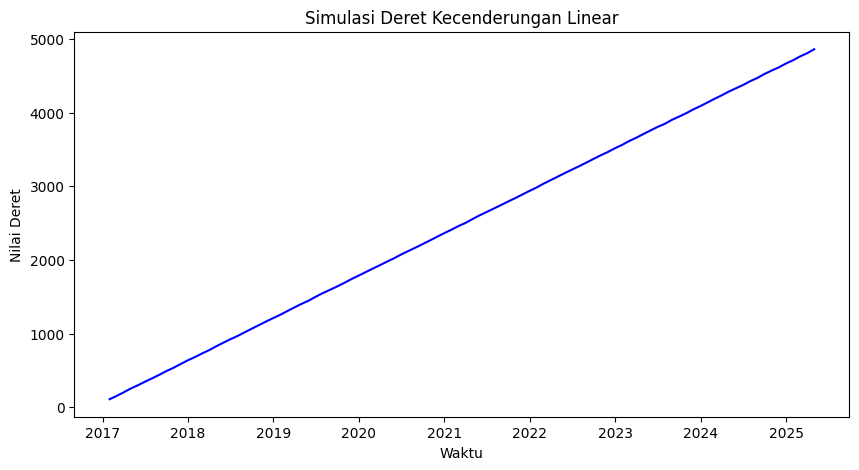

In [7]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?

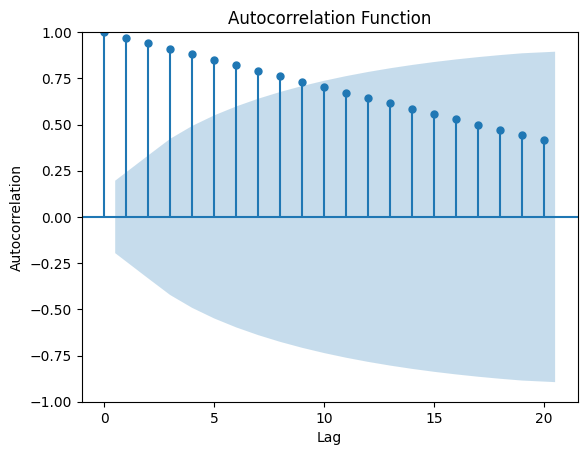

In [22]:
# JAWAB
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(df["Value"], lags=20)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation Function")
plt.show()

**JAWAB:** Plot ACF menunjukkan adanya korelasi antar pengamatan. Hal ini terlihat dari nilai autokorelasi yang sangat tinggi pada lag awal dan menurun secara perlahan seiring bertambahnya lag. Dengan demikian, deret waktu memiliki autokorelasi positif yang kuat yang kemungkinan besar disebabkan oleh adanya kecenderungan linear (trend) pada data.

In [8]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [9]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.252e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.51e-282
Time:                        13:20:56   Log-Likelihood:                -205.70
No. Observations:                 100   AIC:                             415.4
Df Residuals:                      98   BIC:                             420.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          105.9288      0.380    279.096   

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?

Apakah model regresi yang dipaskan sudah bagus?

**JAWAB:** Hasil pengembangan model regresi OLS menunjukkan bahwa model yang diperoleh sangat mendekati model sebenarnya. Parameter asli yang digunakan adalah beta0=106 dan beta1 = 48, sedangkan hasil estimasi masing-masing sebesar 105,9288 dan 48,0018. Selisih antara parameter asli dan hasil estimasi sangat kecil. Selain itu, nilai \(R^2\) sebesar 1,000 menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi data. Koefisien waktu juga signifikan secara statistik dengan \(p<0,001\). Nilai Durbin-Watson sebesar 1,968 yang mendekati 2 menunjukkan bahwa residual tidak mengalami autokorelasi yang berarti. Dengan demikian, model regresi yang dipaskan dapat dikatakan sudah sangat baik dalam menggambarkan deret dengan kecenderungan linear tersebut.

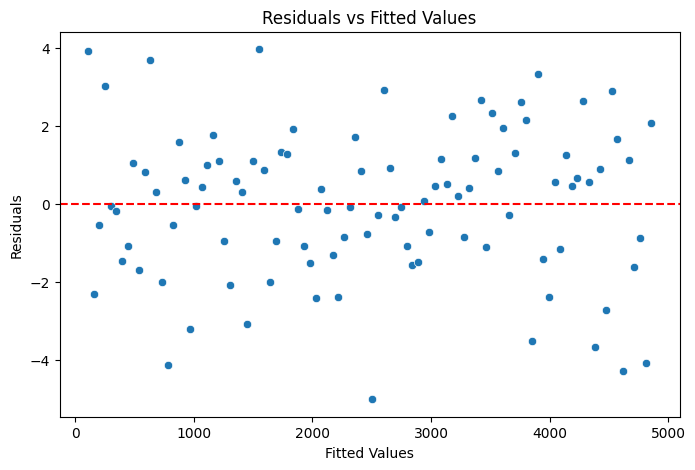

In [10]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?
**JAWAB:** Berdasarkan plot Residuals vs Fitted Values, residual terlihat menyebar secara acak di sekitar garis nol dan tidak membentuk pola tertentu. Hal ini menunjukkan bahwa model regresi linear telah mampu menangkap pola kecenderungan linear pada data dengan baik. Selain itu, tidak terlihat pola penyebaran residual yang semakin melebar atau menyempit secara sistematis, sehingga tidak terdapat indikasi kuat adanya masalah heteroskedastisitas. Dengan demikian, model regresi yang diperoleh dapat dikatakan cukup baik dalam menggambarkan hubungan antara waktu dan nilai deret.

In [11]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.4710


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?
**JAWAB:** Berdasarkan uji Breusch–Pagan diperoleh p-value sebesar 0,4710 yang lebih besar dari taraf signifikansi 5%. Dengan demikian H0 tidak ditolak, sehingga tidak terdapat bukti yang cukup adanya heteroskedastisitas. Varians residual dapat dianggap konstan (homoskedastisitas).

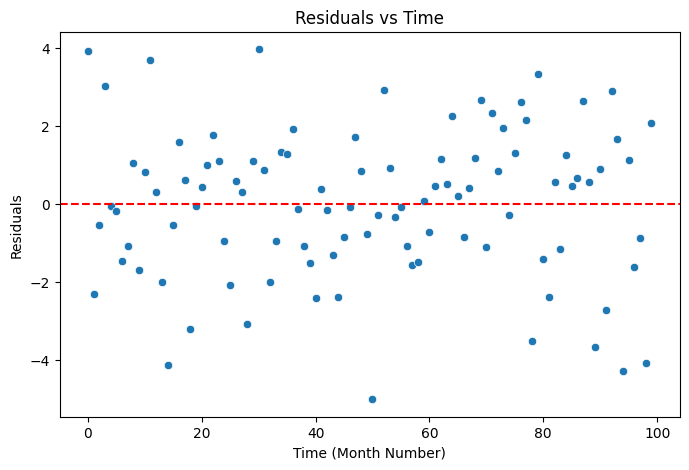

In [12]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

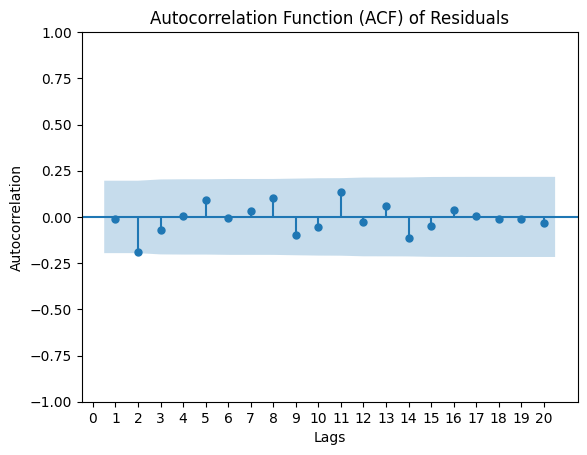

In [13]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


Apa yang dapat Anda simpulkan dari plot di atas?
**JAWAB:** Berdasarkan plot ACF residual, nilai autokorelasi pada sebagian besar lag berada di dalam batas interval kepercayaan dan di sekitar nol. Hal ini menunjukkan bahwa tidak terdapat autokorelasi yang signifikan pada residual. Dengan demikian, residual dapat dianggap saling independen, sehingga asumsi independensi residual pada model regresi telah terpenuhi.

In [14]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.013545   0.907348
2    3.699120   0.157306
3    4.187986   0.241867
4    4.190536   0.380833
5    5.058542   0.408777
6    5.059777   0.536169
7    5.175599   0.638544
8    6.352003   0.607866
9    7.456344   0.589719
10   7.826837   0.645747
11   9.889258   0.540375
12   9.989227   0.616906
13  10.392522   0.661564
14  11.881250   0.615839
15  12.142620   0.668203
16  12.332465   0.720794
17  12.333311   0.779547
18  12.349155   0.828697
19  12.364870   0.869443


Apa kesimpulan dari hasil uji Ljung-Box tersebut?
**JAWAB:** Berdasarkan uji Ljung–Box pada residual hingga lag ke-19, seluruh p-value yang diperoleh lebih besar dari taraf signifikansi 5%. Dengan demikian H0 tidak ditolak, sehingga tidak terdapat bukti yang cukup untuk menyatakan adanya autokorelasi pada residual. Hal ini menunjukkan bahwa residual dapat dianggap independen dan asumsi tidak adanya autokorelasi telah terpenuhi.

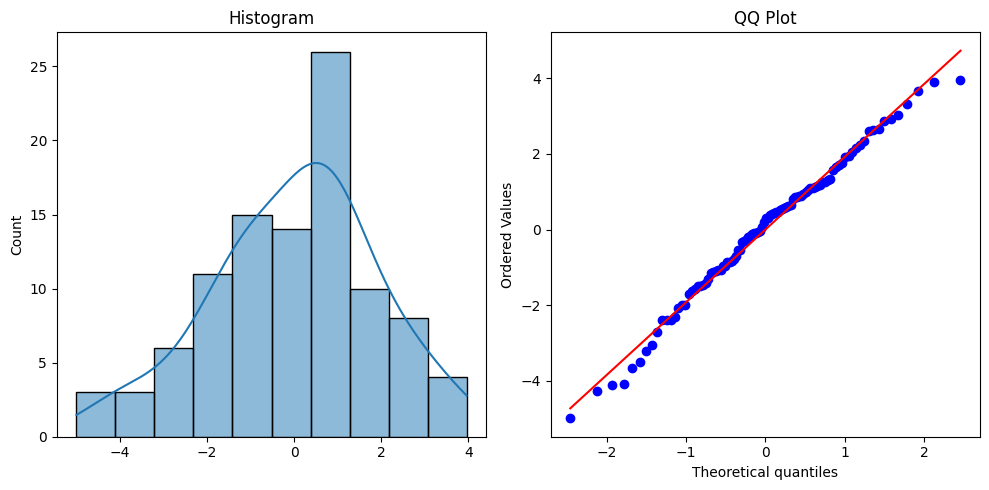

In [15]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?
**JAWAB:** Berdasarkan histogram, distribusi residual cenderung mendekati bentuk normal (simetris di sekitar nol) namun terlihat sedikit lebih runcing dibanding kurva normal teoritisnya, dengan sedikit ekor memanjang ke kiri. Pada QQ plot, sebagian besar titik mengikuti garis referensi dengan cukup baik di bagian tengah, namun terdapat deviasi (penyimpangan) pada kedua ujung (ekor kiri dan kanan) di mana titik-titik menjauh dari garis lurus, mengindikasikan adanya heavy tails (ekor distribusi lebih tebal dari normal). Secara keseluruhan, residual model dapat dikatakan mendekati normal namun belum sepenuhnya memenuhi asumsi normalitas secara sempurna, sehingga disarankan untuk mengonfirmasi dengan uji formal seperti Shapiro-Wilk atau Kolmogorov-Smirnov sebelum menyimpulkan pelanggaran asumsi.

In [16]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9881221142650699, p-value = 0.5172544338420941


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

**JAWAB:** Berdasarkan hasil pemeriksaan (histogram dan QQ plot) yang menunjukkan residual mendekati distribusi normal dengan sedikit deviasi pada bagian ekor, hasil ini diperkuat oleh uji Shapiro-Wilk yang menghasilkan nilai statistik sebesar 0,988 dengan p-value sebesar 0,517. Karena p-value tersebut lebih besar dari taraf nyata α = 0,05, maka keputusannya adalah gagal tolak H0, sehingga dapat disimpulkan bahwa residual model berdistribusi normal.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [17]:
# Menentukan parameter simulasi
np.random.seed(2025)
n_periods = 120
beta_0, beta_1, beta_2= 50+96, 0.5*96, 0.02*96
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

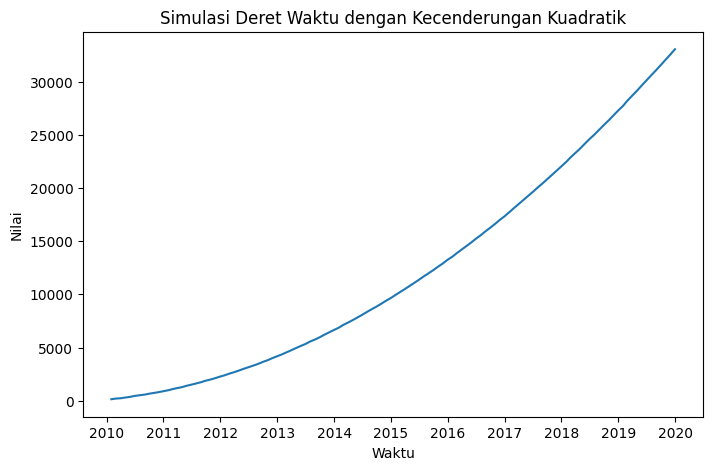

In [18]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

**JAWAB:** Deret waktu ini menunjukkan tren yang melengkung ke atas (kuadratik), bukan garis lurus seperti pada tren linear. Artinya, nilai tidak hanya terus naik, tetapi kenaikannya juga semakin cepat dari tahun ke tahun misalnya kenaikan dari 2010 ke 2011 jauh lebih kecil dibanding kenaikan dari 2019 ke 2020.

Perbedaan pola yang terlihat dibanding tren linear antara lain:

- **Bentuk garis**: tren linear berbentuk garis lurus, sedangkan deret ini berbentuk kurva melengkung ke atas.
- **Kecepatan kenaikan**: pada tren linear, kenaikan antar tahun relatif sama besar (konstan), sedangkan pada deret ini kenaikannya semakin membesar setiap tahun (semakin curam).
- **Percepatan**: tren linear tidak memiliki percepatan (naik dengan kecepatan tetap), sedangkan deret ini memperlihatkan percepatan pertumbuhan, terutama terlihat jelas mulai tahun 2016 ke atas.
- **Model yang cocok**: tren linear cukup digambarkan dengan persamaan garis lurus, sedangkan deret ini lebih cocok digambarkan dengan persamaan kuadratik (melibatkan waktu kuadrat) karena adanya kelengkungan pada polanya.

In [19]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.146e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:22:20   Log-Likelihood:                -441.14
No. Observations:                 120   AIC:                             888.3
Df Residuals:                     117   BIC:                             896.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        147.7612      2.607     56.679      0.0

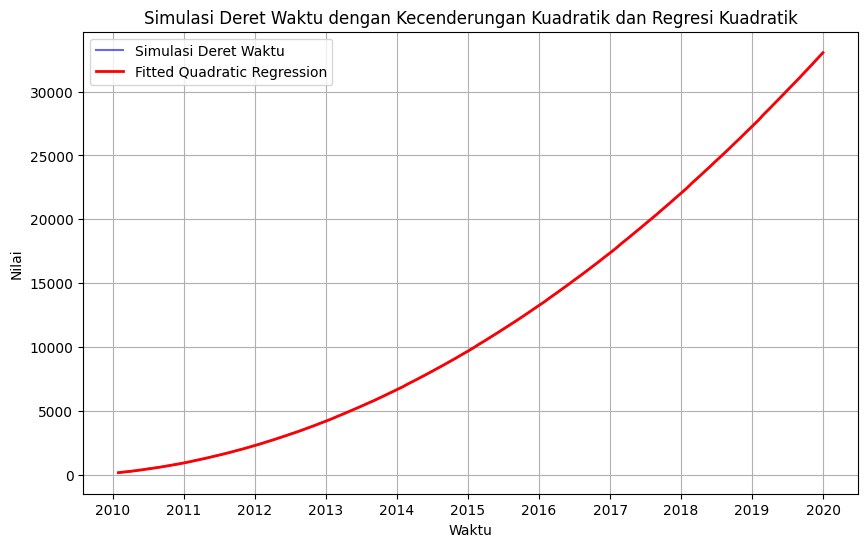

In [20]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!

Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!

Shapiro-Wilk Test: Statistics = 0.9838650151541777, p-value = 0.16214857063696564
{'LM Statistic': np.float64(1.662984244687582), 'LM p-value': np.float64(0.4353991326134853), 'F-Statistic': np.float64(0.822097614117471), 'F p-value': np.float64(0.44203124078327083)}
Durbin-Watson Statistic: 2.1982064003742297


<Figure size 800x400 with 0 Axes>

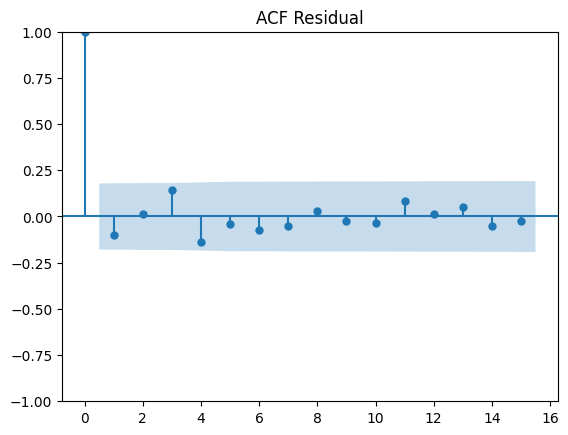

In [25]:
# cek asumsi model regresi kuadratik
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf

# Ambil residual dan fitted values dari model
resid = model_quad.resid
fitted = model_quad.fittedvalues

# ============================================
# 1. UJI NORMALITAS RESIDUAL

# Uji Shapiro-Wilk
sw_stat, sw_p = stats.shapiro(resid)
print(f"Shapiro-Wilk Test: Statistics = {sw_stat}, p-value = {sw_p}")

# ============================================
# 2. UJI HOMOSKEDASTISITAS
# ============================================

# Uji Breusch-Pagan
bp_test = het_breuschpagan(resid, model_quad.model.exog)
labels = ['LM Statistic', 'LM p-value', 'F-Statistic', 'F p-value']
print(dict(zip(labels, bp_test)))

# ============================================
# 3. UJI AUTOKORELASI (khusus data deret waktu)
# ============================================
# Uji Durbin-Watson
dw_stat = durbin_watson(resid)
print(f"Durbin-Watson Statistic: {dw_stat}")

# Plot ACF Residual
plt.figure(figsize=(8,4))
plot_acf(resid, lags=15)
plt.title('ACF Residual')
plt.show()


**JAWAB:** Berdasarkan hasil pengujian asumsi, residual model regresi kuadratik berdistribusi normal (Shapiro-Wilk, p-value = 0,162), memiliki varians yang homogen atau tidak terjadi heteroskedastisitas (Breusch-Pagan, p-value = 0,435), serta tidak terdapat autokorelasi antar residual (Durbin-Watson = 2,198, didukung oleh seluruh lag pada plot ACF yang berada dalam batas signifikansi). Dengan terpenuhinya seluruh asumsi klasik OLS tersebut, dapat disimpulkan bahwa model regresi kuadratik yang digunakan sudah tepat dan sesuai untuk memodelkan pola tren pada deret waktu tersebut.

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [26]:
# Menentukan parameter simulasi
np.random.seed(100)
n_periods = 120
beta0, beta1, beta2=50+96,-25*96, -2*96
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


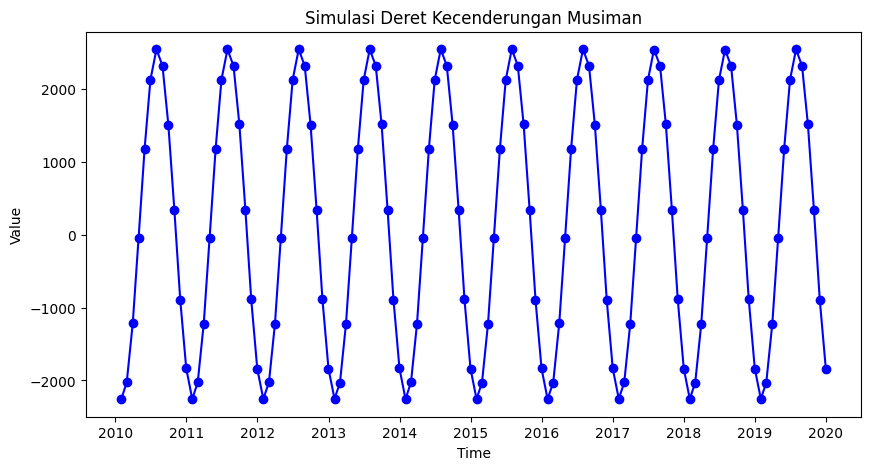

In [27]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

**JAWAB:** Deret waktu ini menunjukkan pola musiman (seasonal) yang berulang secara periodik dengan periode 12, artinya pola naik-turun nilai kembali terulang setiap 12 satuan waktu (misalnya setiap 1 tahun jika satuan waktunya bulanan). Terlihat jelas bahwa bentuk gelombang pada setiap siklus (misalnya 2010–2011, 2011–2012, dan seterusnya) memiliki pola, amplitudo (rentang naik-turun sekitar -2300 hingga 2500), serta titik puncak dan lembah yang hampir identik dari tahun ke tahun, tanpa disertai kecenderungan naik atau turun jangka panjang (tidak ada tren). Dengan kata lain, deret ini murni digerakkan oleh faktor musiman yang konsisten dan berulang, sehingga rata-rata nilainya relatif stabil di sekitar nol sepanjang waktu, tidak seperti pola tren (linear atau kuadratik) yang nilainya terus bergerak naik/turun secara sistematis.

In [28]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [29]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [30]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [31]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 8.263e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.65e-314
Time:                        13:49:22   Log-Likelihood:                -244.46
No. Observations:                 120   AIC:                             512.9
Df Residuals:                     108   BIC:                             546.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari    -2254.5532      0.619  -3645.066      0.0

Bagaimana interpretasi dari hasil tersebut?

**JAWAB:** Model regresi tanpa intercept ini menggunakan variabel dummy bulanan (Januari–Desember) sebagai prediktor, sehingga setiap koefisien langsung merepresentasikan nilai rata-rata (mean) deret pada bulan tersebut, bukan selisih terhadap kategori acuan. Nilai R-squared sebesar 1,000 dan F-statistic yang sangat besar (8,263e+06) dengan p-value mendekati nol menunjukkan bahwa model ini menjelaskan hampir seluruh variasi data secara sempurna, yang wajar karena pola musiman pada data bersifat deterministik dan berulang secara identik setiap tahun. Seluruh koefisien bulanan signifikan secara statistik (p-value = 0,000), dengan pola nilai yang jelas mengikuti bentuk gelombang musiman: nilai terendah terjadi pada Januari (-2254,55) dan Februari (-2028,28), meningkat bertahap hingga puncaknya pada Juli (2545,25), lalu menurun kembali menuju Desember (-1836,51) — pola ini konsisten dengan bentuk gelombang musiman yang terlihat pada plot sebelumnya. Selain itu, nilai Durbin-Watson sebesar 1,982 (mendekati 2) mengindikasikan tidak adanya autokorelasi pada residual, sedangkan uji Jarque-Bera (p-value = 0,543) menunjukkan residual berdistribusi normal. Secara keseluruhan, model dummy bulanan tanpa intercept ini sangat tepat dan mampu menangkap pola musiman pada deret waktu tersebut secara akurat.


In [32]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

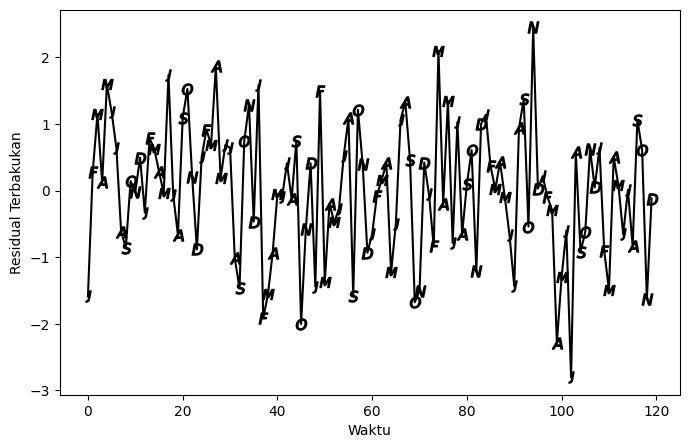

In [33]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


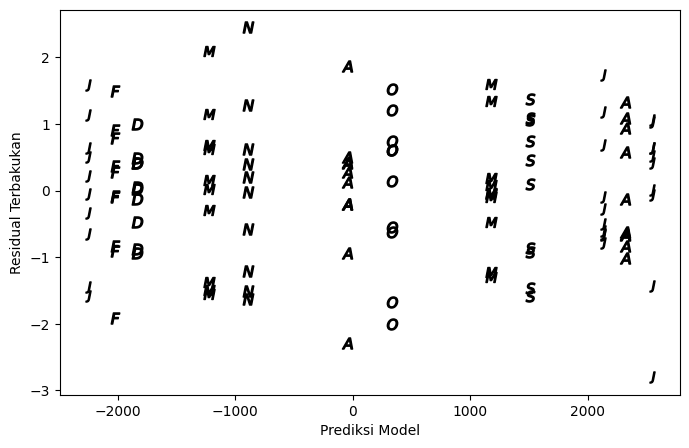

In [34]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

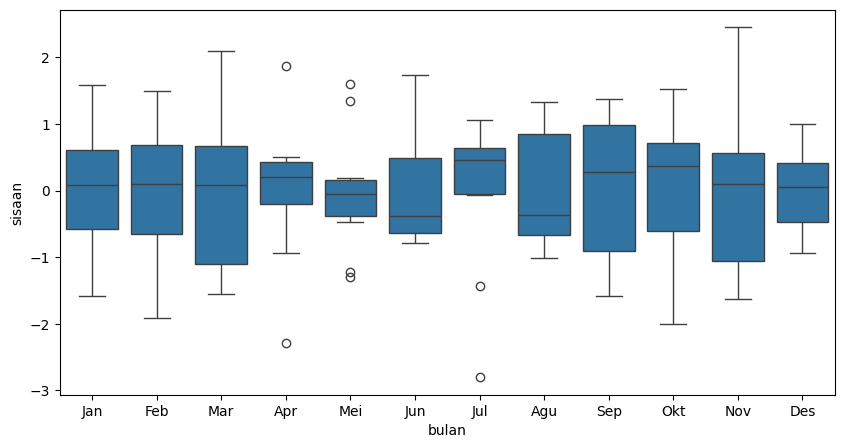

In [37]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?

**JAWAB:**

**Plot 1 (Residual vs Waktu):** residual terbakukan berfluktuasi secara acak di sekitar nol sepanjang waktu (rentang sekitar -3 hingga 2,5) tanpa memperlihatkan pola tren, siklus, atau perubahan variansi yang sistematis. Sebaran simbol bulan juga tidak menunjukkan pengelompokan tertentu pada rentang waktu tertentu, mengindikasikan model musiman sudah cukup baik menangkap pola data dan residual berperilaku seperti white noise.

**Plot 2 (Residual vs Prediksi Model):** titik-titik residual tersebar secara acak di sekitar garis nol pada semua level nilai prediksi (dari sekitar -2000 hingga 2500), tanpa membentuk pola melengkung, corong (funnel), atau tren tertentu terhadap nilai fitted. Ini mengindikasikan asumsi homoskedastisitas (variansi residual konstan) terpenuhi dan tidak ada indikasi model salah spesifikasi (misalnya kebutuhan transformasi atau term tambahan).

**Plot 3 (Boxplot Residual per Bulan):** median residual pada hampir seluruh bulan berada di sekitar nol dengan sebaran (IQR) yang relatif sebanding antar bulan, meskipun terdapat beberapa outlier pada bulan Maret, April, Mei, dan Juli. Tidak terlihat adanya bulan tertentu yang secara sistematis memiliki residual jauh lebih tinggi/rendah dari nol, sehingga mengindikasikan bahwa komponen musiman sudah ditangkap dengan baik oleh model dan tidak ada pola musiman residual yang tersisa.

**Kesimpulan keseluruhan:** ketiga plot secara konsisten menunjukkan bahwa residual model musiman berperilaku acak (tidak berpola) baik terhadap waktu, nilai prediksi, maupun bulan, sehingga dapat disimpulkan bahwa model regresi musiman yang digunakan sudah sesuai (adequate) dan tidak menyisakan pola sistematis yang seharusnya dijelaskan lebih lanjut oleh model.

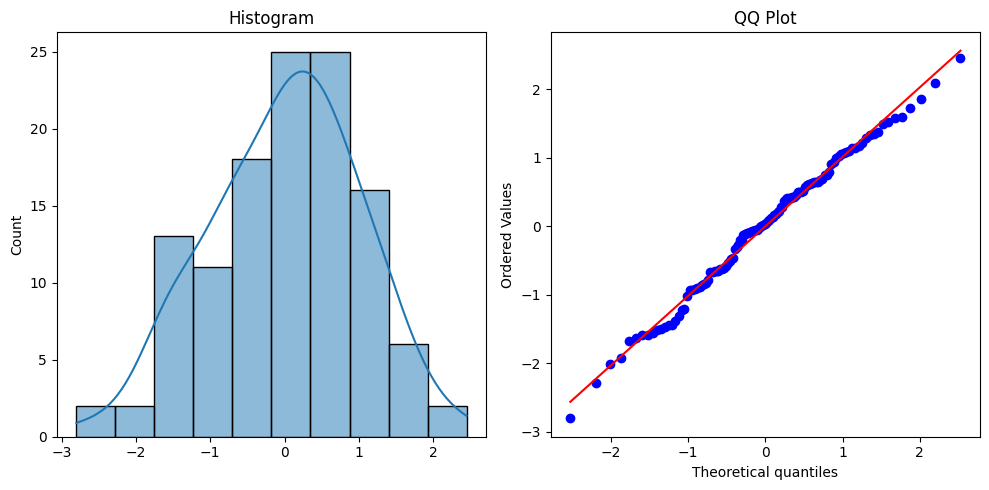

In [38]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

Hitunglah statistik uji untuk mengecek asumsi model

In [48]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep
# Uji Shapiro-Wilk
sw_stat, sw_p = stats.shapiro(std_resid)
print(f"Shapiro-Wilk Test: Statistics = {sw_stat}, p-value = {sw_p}")

Shapiro-Wilk Test: Statistics = 0.9922960122165382, p-value = 0.7487496520299463


**JAWAB:** Hasil uji Shapiro-Wilk menunjukkan nilai statistik = 0,992 dengan p-value = 0,749. Karena p-value tersebut jauh lebih besar dari taraf nyata α = 0,05, maka keputusannya adalah gagal tolak H0, yang berarti **residual model berdistribusi normal**.

Hasil ini konsisten dengan interpretasi visual sebelumnya pada histogram dan QQ plot, di mana residual tampak mendekati distribusi normal meskipun ada sedikit deviasi pada ekor. Uji formal ini mengonfirmasi bahwa deviasi tersebut tidak signifikan secara statistik.

**Kesimpulan:** dengan terpenuhinya asumsi normalitas residual (didukung sebelumnya oleh hasil homoskedastisitas dan non-autokorelasi yang baik dari analisis plot residual terhadap waktu, prediksi, dan bulan), maka dapat dikatakan bahwa **model regresi musiman tanpa intercept yang dipaskan sudah tepat** dalam menangkap pola pada deret waktu tersebut.

In [43]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [42]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 8.263e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.65e-314
Time:                        13:57:05   Log-Likelihood:                -244.46
No. Observations:                 120   AIC:                             512.9
Df Residuals:                     108   BIC:                             546.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2254.5532      0.619  -3645.066      0.0

In [51]:
# uji asumsi model dengan intersep
import numpy as np
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Ambil residual dan fitted values dari model dengan intercept
resid = musiman_int.resid
fitted = musiman_int.fittedvalues

# 1. Uji Normalitas (Shapiro-Wilk)
sw_stat, sw_p = stats.shapiro(resid)
print(f"Shapiro-Wilk Test: Statistics = {sw_stat}, p-value = {sw_p}")

# 2. Uji Homoskedastisitas (Breusch-Pagan)
bp_test = het_breuschpagan(resid, musiman_int.model.exog)
labels = ['LM Statistic', 'LM p-value', 'F-Statistic', 'F p-value']
print(dict(zip(labels, bp_test)))

# 3. Uji Autokorelasi (Durbin-Watson)
dw_stat = durbin_watson(resid)
print(f"Durbin-Watson Statistic: {dw_stat}")

Shapiro-Wilk Test: Statistics = 0.9922960122165343, p-value = 0.7487496520295956
{'LM Statistic': np.float64(7.000866499700167), 'LM p-value': np.float64(0.7990133260534863), 'F-Statistic': np.float64(0.6082859049418466), 'F p-value': np.float64(0.818282591513699)}
Durbin-Watson Statistic: 1.9821683231558171


Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Apakah model dengan intersep sudah memenuhi asumsi regresi?

**JAWAB:**

**Perbandingan koefisien:**
Model tanpa intercept memakai 12 dummy bulan, sehingga tiap koefisien = rata-rata langsung nilai pada bulan tersebut. Model dengan intercept memakai 11 dummy bulan (satu bulan jadi acuan) + konstanta, sehingga konstanta = rata-rata bulan acuan, dan tiap koefisien dummy = selisih rata-rata bulan tersebut terhadap bulan acuan. Fitted values kedua model identik, hanya cara pemaknaan koefisiennya berbeda (nilai absolut vs relatif).

**Uji asumsi model dengan intercept:**
- Normalitas (Shapiro-Wilk): p-value = 0,749 (>0,05) → residual normal
- Homoskedastisitas (Breusch-Pagan): p-value = 0,818 (>0,05) → tidak ada heteroskedastisitas
- Autokorelasi (Durbin-Watson): 1,982 (≈2) → tidak ada autokorelasi

**Kesimpulan:** Ketiga asumsi terpenuhi, hasilnya sama dengan model tanpa intercept, sehingga model dengan intercept ini juga sudah tepat digunakan.

## Kecenderungan Linear dan Musiman

In [52]:
# Parameter
np.random.seed(22025)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5*96, 10*96 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


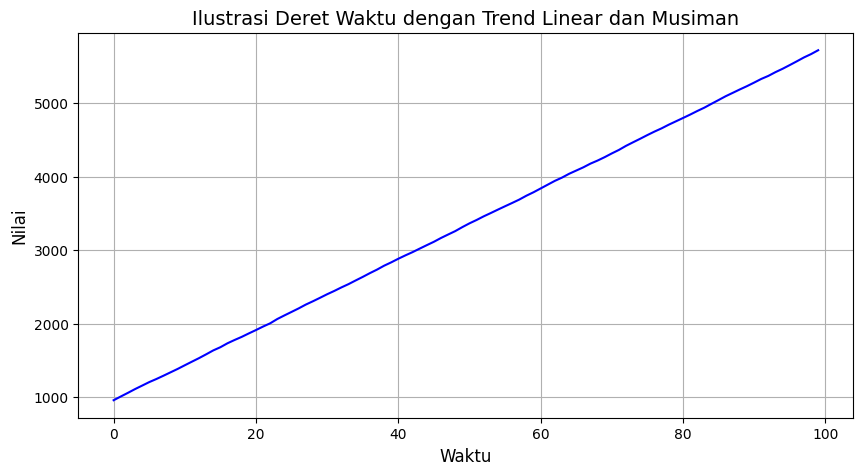

In [53]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [55]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [56]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [57]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.276e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.70e-245
Time:                        14:07:33   Log-Likelihood:                -200.88
No. Observations:                 100   AIC:                             427.8
Df Residuals:                      87   BIC:                             461.6
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      960.1295      0.721   1332.227      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

**JAWAB:** Karena model ini tidak memiliki intercept terpisah (seluruh 12 dummy bulan dimasukkan), cara memaknai koefisiennya sebagai berikut:

- **Koefisien tiap bulan (Januari–Desember)**: menunjukkan **nilai dasar (baseline) deret pada bulan tersebut saat period = 0** (awal periode pengamatan). Misalnya, koefisien Mei = 965,3789 berarti pada awal periode, nilai deret pada bulan Mei diperkirakan sebesar 965,38. Pola nilai antar bulan relatif berdekatan (berkisar 955–965), naik dari Januari ke puncaknya di Mei, lalu turun hingga terendah di Oktober, kemudian naik lagi menuju Desember — mencerminkan pola musiman dengan amplitudo yang relatif kecil.

- **Koefisien `period` (47,9936)**: menunjukkan **laju tren linear**, yaitu rata-rata kenaikan nilai deret sebesar 47,99 unit untuk setiap pertambahan satu satuan waktu (period), dengan mengontrol efek musiman bulanan. Nilai t-statistic yang sangat besar (7147,558) dan p-value = 0,000 menunjukkan tren ini sangat signifikan dan dominan dibanding variasi musimannya.

Nilai prediksi deret pada waktu tertentu diperoleh dengan menjumlahkan **baseline musiman bulan yang bersangkutan** dengan **efek tren** (47,9936 × period). Nilai R-squared = 1,000 dan F-statistic yang sangat besar mengonfirmasi bahwa kombinasi tren linear dan musiman ini menjelaskan hampir seluruh variasi data secara sempurna, di mana komponen tren jauh lebih dominan (koefisien besar) dibanding komponen musiman (variasi baseline antar bulan relatif kecil).

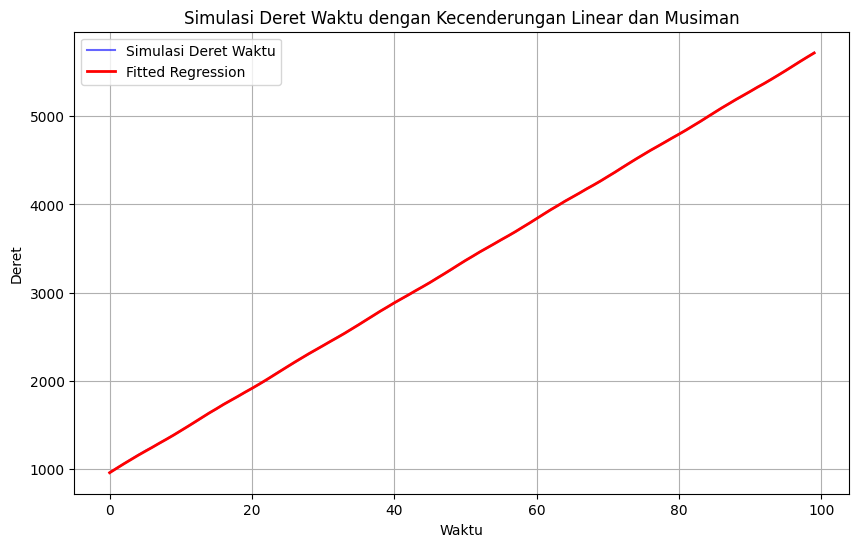

In [58]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

In [59]:
# uji asumsi model
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan

resid = model.resid  # ganti 'model' dengan nama variabel model Anda

# Konfirmasi normalitas
sw_stat, sw_p = stats.shapiro(resid)
print(f"Shapiro-Wilk Test: Statistics = {sw_stat}, p-value = {sw_p}")

# Uji homoskedastisitas
bp_test = het_breuschpagan(resid, model.model.exog)
labels = ['LM Statistic', 'LM p-value', 'F-Statistic', 'F p-value']
print(dict(zip(labels, bp_test)))

Shapiro-Wilk Test: Statistics = 0.9881221142650699, p-value = 0.5172544338420941
{'LM Statistic': np.float64(0.5196326719385969), 'LM p-value': np.float64(0.4709984157452276), 'F-Statistic': np.float64(0.5119000182422756), 'F p-value': np.float64(0.4760186980753335)}


Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

**JAWAB:**

Berdasarkan hasil lengkap uji asumsi:

- **Normalitas (Shapiro-Wilk)**: statistik = 0,988, p-value = 0,517 (> 0,05) → gagal tolak H0, **residual berdistribusi normal**.
- **Homoskedastisitas (Breusch-Pagan)**: LM p-value = 0,471, F p-value = 0,476 (keduanya > 0,05) → gagal tolak H0, **tidak ada heteroskedastisitas** (varians residual homogen).
- **Autokorelasi (Durbin-Watson)**: 2,005 (≈2, dari summary sebelumnya) → **tidak ada autokorelasi**.

**Kesimpulan:** Seluruh hasil uji menunjukkan **tidak ada pelanggaran asumsi klasik OLS** — residual berdistribusi normal, varians residual homogen, dan tidak ada autokorelasi antar residual. Dengan demikian, model regresi tren + musiman ini telah memenuhi seluruh asumsi yang disyaratkan, sehingga dapat dikatakan **model sudah tepat (adequate)** digunakan untuk memodelkan pola data yang memiliki komponen tren linear sekaligus musiman.

In [60]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

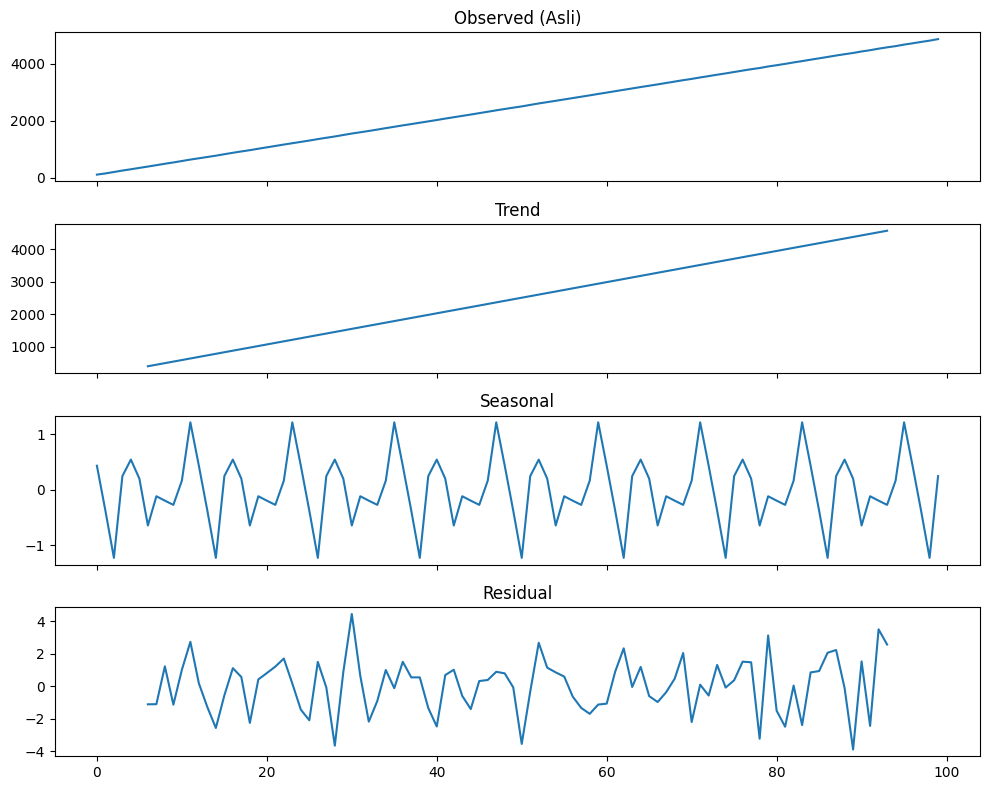

In [61]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

**JAWAB:** Hasil dekomposisi deret waktu ini memisahkan data asli menjadi tiga komponen utama:

**Observed (Asli)** menunjukkan data mentah yang terus meningkat secara konsisten dari sekitar 0 hingga mendekati 4500-5000, mencerminkan adanya kecenderungan naik yang kuat sepanjang periode pengamatan.

**Trend** memperlihatkan pola kenaikan yang halus dan hampir linear, sangat mirip bentuknya dengan data observed — ini mengindikasikan bahwa **komponen tren mendominasi** pergerakan data asli, sejalan dengan hasil regresi sebelumnya di mana koefisien `period` (47,99) jauh lebih besar dan dominan dibanding variasi musiman antar bulan.

**Seasonal** menunjukkan pola musiman yang **stasioner dan berulang secara identik** sepanjang waktu, dengan amplitudo tetap (kira-kira -1,3 hingga 1,2) dan periode berulang yang konsisten (terlihat dari bentuk gelombang yang sama persis pada setiap siklusnya). Ini konsisten dengan variasi baseline antar bulan pada koefisien regresi yang relatif kecil (berkisar 955-965) dibanding besarnya efek tren.

**Residual** berfluktuasi acak di sekitar nol (rentang sekitar -4 hingga 4) tanpa pola sistematis yang jelas (tidak ada tren atau siklus tersisa), mengindikasikan bahwa **model dekomposisi (tren + musiman) sudah cukup baik menangkap struktur data**, dan sisa variasi yang tidak terjelaskan bersifat random/noise.

**Kesimpulan keseluruhan:** deret waktu ini didominasi oleh komponen tren linear yang kuat, disertai pola musiman dengan amplitudo relatif kecil dan konsisten, serta residual yang berperilaku acak — mengonfirmasi bahwa data ini cocok dimodelkan dengan pendekatan aditif (tren + musiman + noise), sejalan dengan hasil regresi tren-musiman yang telah memenuhi seluruh asumsi klasik OLS sebelumnya.

In [62]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

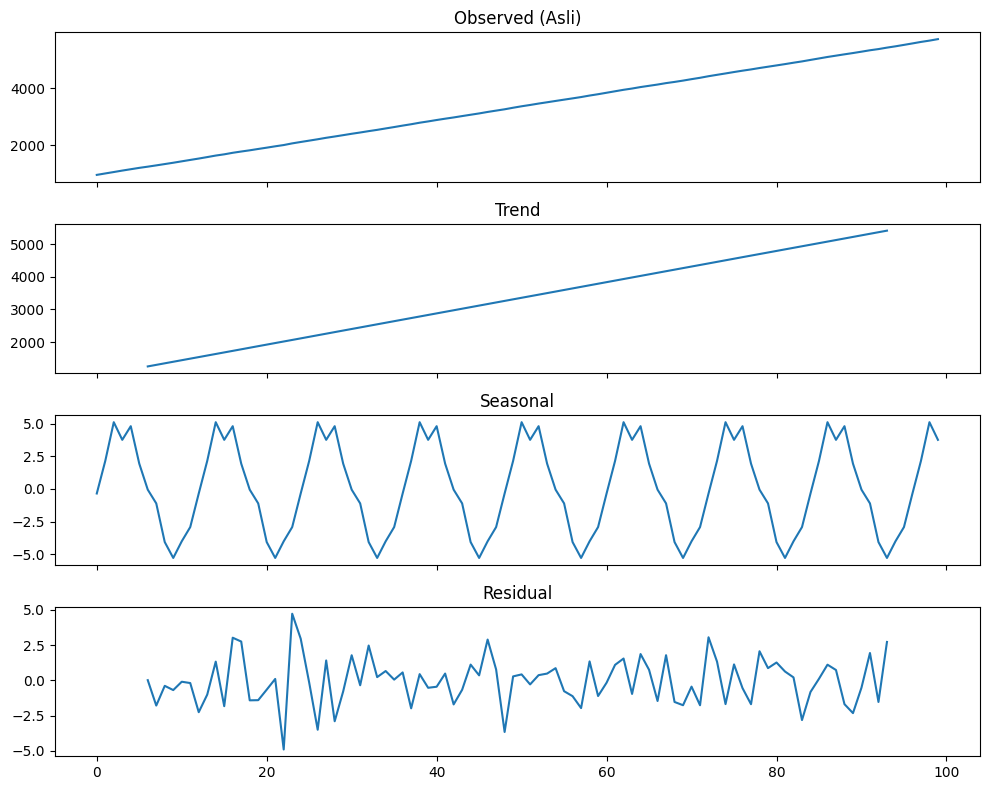

In [63]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

**JAWAB:**

Hasil dekomposisi deret waktu ini menunjukkan pola yang serupa strukturnya dengan sebelumnya, namun dengan amplitudo musiman yang lebih besar:

**Observed (Asli)** menunjukkan data mentah yang meningkat secara konsisten dari sekitar 500 hingga mendekati 5000-5500, mengindikasikan tren naik yang kuat sepanjang periode pengamatan.

**Trend** memperlihatkan garis kenaikan yang halus dan hampir linear (dari sekitar 1000 hingga 5300), sangat mirip bentuknya dengan pola data observed — menunjukkan bahwa **komponen tren mendominasi** pergerakan jangka panjang data.

**Seasonal** menunjukkan pola musiman yang **stasioner dan berulang secara identik** sepanjang waktu, dengan amplitudo tetap berkisar antara -5 hingga 5, dan bentuk gelombang yang konsisten pada setiap siklusnya (terlihat ada sekitar 10 siklus berulang dalam 100 periode, sehingga periode musimannya sekitar 10). Dibanding dekomposisi sebelumnya, amplitudo musiman di sini jauh lebih besar (-5 hingga 5, dibanding -1,3 hingga 1,2 sebelumnya), sehingga kontribusi komponen musiman terhadap data asli lebih terlihat jelas.

**Residual** berfluktuasi acak di sekitar nol (rentang sekitar -5 hingga 5) tanpa pola sistematis yang jelas (tidak ada tren atau siklus tersisa), meski terdapat satu titik yang cukup ekstrem di sekitar periode ke-23 (turun tajam mendekati -5). Secara umum pola ini masih mengindikasikan sisa variasi bersifat acak/noise.

**Kesimpulan:** deret waktu ini juga didominasi oleh komponen tren linear yang kuat, namun disertai pola musiman dengan amplitudo yang lebih besar dan lebih dominan dibanding kasus sebelumnya, serta residual yang secara umum berperilaku acak — sehingga data ini tetap cocok dimodelkan dengan pendekatan aditif (tren + musiman + noise), meskipun kontribusi relatif komponen musiman terhadap variasi total data di sini lebih besar dibanding kasus dekomposisi sebelumnya.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [ ]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(22025)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05, 10 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

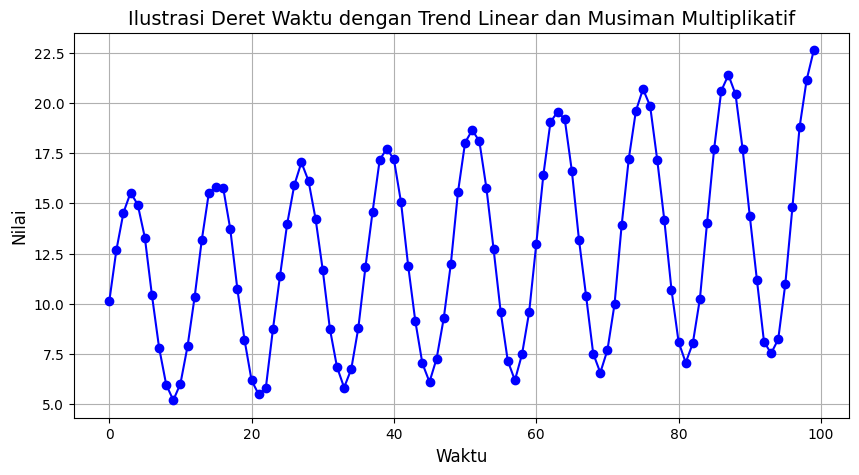

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [ ]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

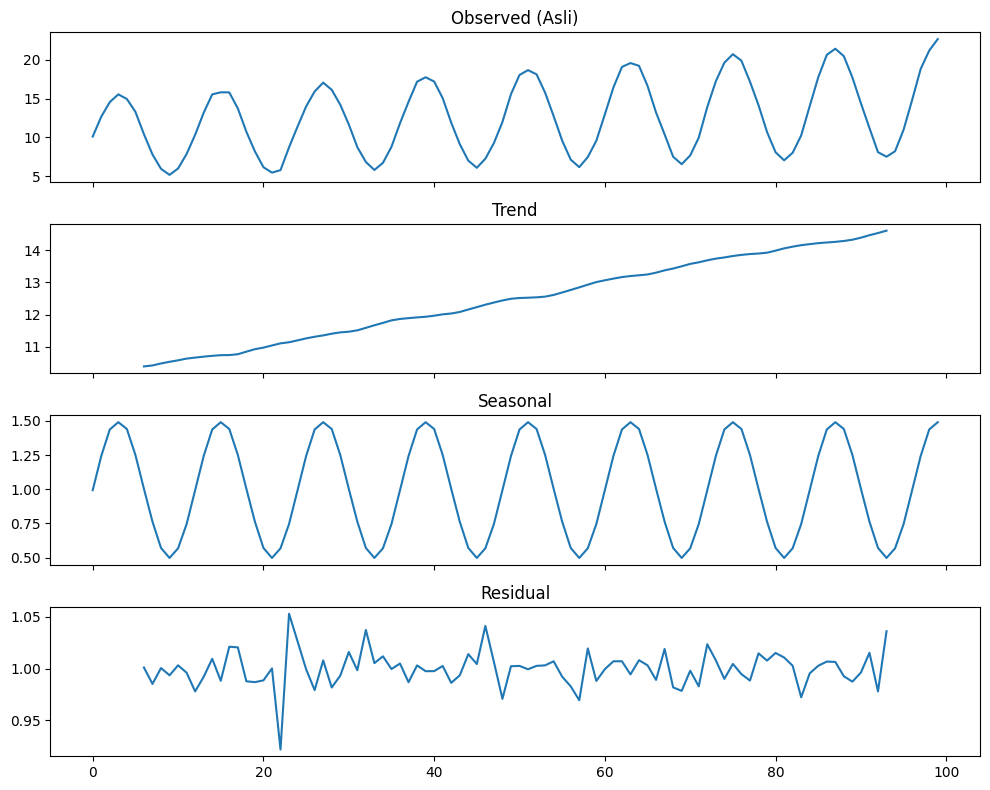

In [ ]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

**JAWAB:**

Plot ini merupakan hasil dekomposisi **multiplikatif** (bukan aditif), sehingga interpretasinya berbeda dari dua kasus sebelumnya — komponen Seasonal dan Residual di sini berupa **rasio** yang berpusat di sekitar 1 (bukan di sekitar 0 seperti pada dekomposisi aditif).

**Observed (Asli)** menunjukkan data berosilasi naik-turun secara berulang (antara sekitar 5 hingga 22) dengan pola gelombang yang amplitudonya semakin membesar seiring waktu — puncak dan lembahnya makin melebar (misalnya lembah awal di sekitar 6, lembah akhir tetap di sekitar 7-8, tapi puncaknya naik dari 15 menjadi 22). Ini adalah ciri khas data yang cocok untuk dekomposisi multiplikatif, karena besarnya fluktuasi musiman berubah proporsional mengikuti level trennya.

**Trend** menunjukkan kenaikan yang halus dan bertahap dari sekitar 10,5 menjadi 14,5, mencerminkan tren jangka panjang yang naik namun dengan laju yang relatif landai.

**Seasonal** berupa rasio yang berulang secara identik dengan periode tetap (sekitar 10 satuan waktu per siklus), berkisar antara 0,5 hingga 1,5. Artinya, pada puncak musiman nilai data sekitar **1,5 kali (150%)** dari nilai trennya, sedangkan pada titik terendah musiman nilainya sekitar **0,5 kali (50%)** dari trennya — bukan penambahan/pengurangan nilai absolut seperti pada model aditif, melainkan **faktor pengali** terhadap tren.

**Residual** juga berupa rasio yang berfluktuasi di sekitar 1 (rentang kira-kira 0,92 hingga 1,05), menandakan penyimpangan acak sebesar beberapa persen saja dari nilai yang diprediksi oleh (Trend × Seasonal), tanpa pola sistematis yang tersisa — mengindikasikan model multiplikatif ini sudah cukup baik menangkap struktur data.

**Kesimpulan:** karena amplitudo musiman pada data asli membesar seiring meningkatnya tren, pendekatan **dekomposisi multiplikatif** (Observed = Trend × Seasonal × Residual) lebih tepat digunakan dibanding model aditif, dan hasil dekomposisi ini menunjukkan pemisahan komponen yang baik — tren naik landai, pola musiman proporsional konsisten, dan residual acak di sekitar 1 tanpa pola sistematis yang tersisa.

In [64]:
# Parameter
np.random.seed(22025)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

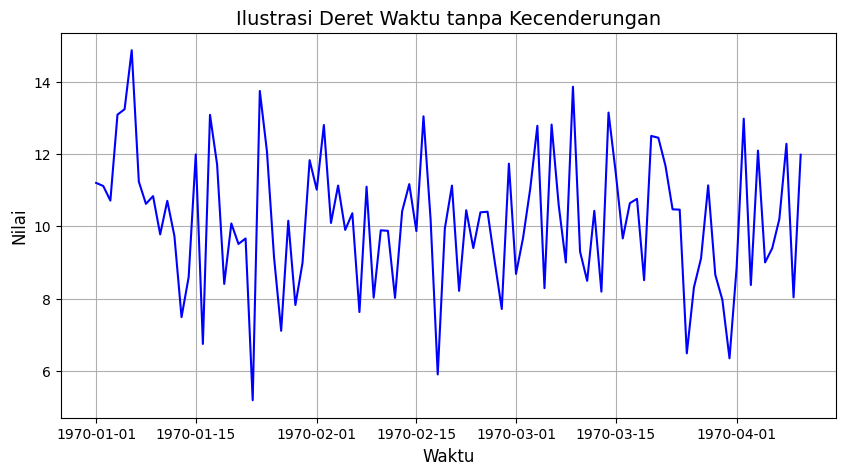

In [65]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

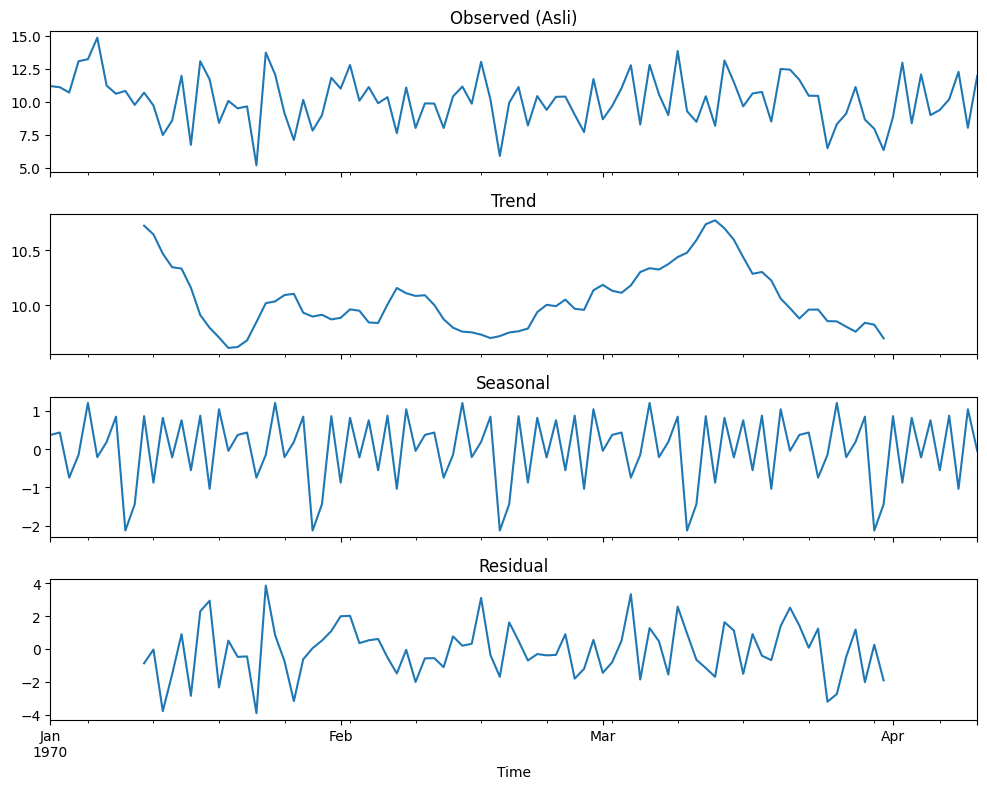

In [66]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?

**JAWAB:**

Hasil dekomposisi aditif ini menunjukkan pola yang cukup berbeda dari kasus-kasus sebelumnya — di sini tidak ada tren jangka panjang yang jelas, dan komponen musiman/residual tampak tidak dominan menjelaskan pola data.

**Observed (Asli)** menunjukkan data berfluktuasi secara acak di sekitar nilai 10 (rentang sekitar 5 hingga 15) tanpa pola kenaikan/penurunan jangka panjang yang jelas, dan tanpa pola musiman yang tampak konsisten secara visual pada level ini.

**Trend** memperlihatkan pergerakan naik-turun yang lambat dan berombak (bukan tren monoton naik atau turun), berkisar antara sekitar 9 hingga 11 — ini lebih menyerupai **siklus jangka menengah** daripada tren dalam arti klasik (kecenderungan searah jangka panjang), yang mengindikasikan mungkin data ini tidak memiliki tren yang kuat, atau smoothing window yang digunakan menangkap fluktuasi jangka menengah sebagai "trend".

**Seasonal** menunjukkan pola yang berulang namun dengan amplitudo relatif kecil (kira-kira -2 hingga 1,3), dan bentuknya tampak lebih **bergerigi/tidak terlalu mulus** dibanding kasus-kasus dekomposisi sebelumnya (yang gelombangnya rapi menyerupai sinus).

**Residual** memiliki rentang yang cukup besar (sekitar -4 hingga 4) **dan sebanding atau bahkan lebih besar dari komponen seasonal-nya sendiri** — ini adalah sinyal penting bahwa model dekomposisi (tren + musiman) **belum banyak menjelaskan variasi data**, sisa (residual) yang besar berarti sebagian besar variasi pada data asli belum tertangkap oleh komponen tren maupun musiman.

**Kesimpulan:** dibanding dua kasus dekomposisi sebelumnya (aditif dan multiplikatif) yang residualnya jauh lebih kecil dibanding komponen tren/musiman, pada kasus ini **residual berkontribusi besar terhadap variasi total data**, mengindikasikan bahwa data asli kemungkinan besar didominasi oleh **noise/random fluctuation** dengan komponen tren dan musiman yang lemah — sehingga model dekomposisi (tren+musiman) di sini kurang informatif/kurang mampu menjelaskan pola data dibanding kedua kasus sebelumnya.